In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Read titanic.csv. If the file is not here, download it once and save it.
# (This is try / except from Class 12!)
try:
    df = pd.read_csv("diamonds.csv")
except FileNotFoundError:
    sns.load_dataset("diamonds.csv").to_csv("diamonds.csv", index=False)   # needs internet
    df = pd.read_csv("diamonds.csv")

In [3]:
#checking the rows
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [11]:
df.shape

(53940, 10)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [5]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [13]:
df.describe().round(1)

,carat,depth,table,price,x,y,z
count,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0
mean,0.8,61.7,57.5,3932.8,5.7,5.7,3.5
std,0.5,1.4,2.2,3989.4,1.1,1.1,0.7
min,0.2,43.0,43.0,326.0,0.0,0.0,0.0
25%,0.4,61.0,56.0,950.0,4.7,4.7,2.9
50%,0.7,61.8,57.0,2401.0,5.7,5.7,3.5
75%,1.0,62.5,59.0,5324.2,6.5,6.5,4.0
max,5.0,79.0,95.0,18823.0,10.7,58.9,31.8


In [7]:
#cleaning the columns
clean = df.drop(columns = ["cut","color","x","y","z","clarity"])

# Remove bad rows first (some diamonds have 0 for x, y, or z)
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]

df["volume"] = df["x"] * df["y"] * df["z"]

In [34]:
duplicate = df.duplicated().sum()
df=df.drop_duplicates()
df.shape

(53775, 11)

In [15]:
df.shape

(53920, 11)

In [14]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250


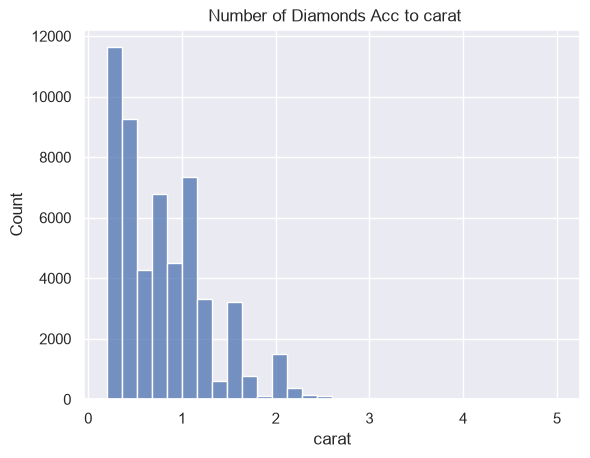

In [16]:
sns.histplot(data = df, x="carat", bins = 30)
plt.title(" Number of Diamonds Acc to carat")
plt.show()


<BarContainer object of 53920 artists>

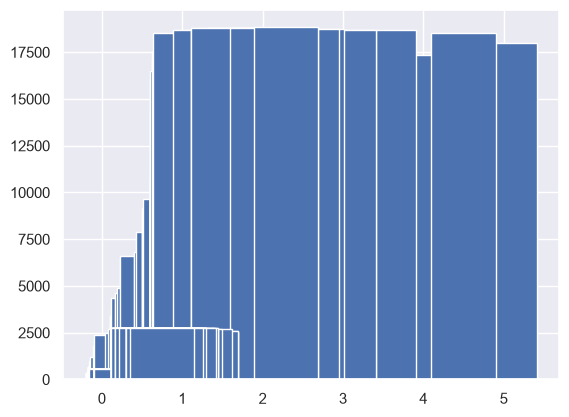

In [19]:
plt.bar(df["carat"], df["price"])

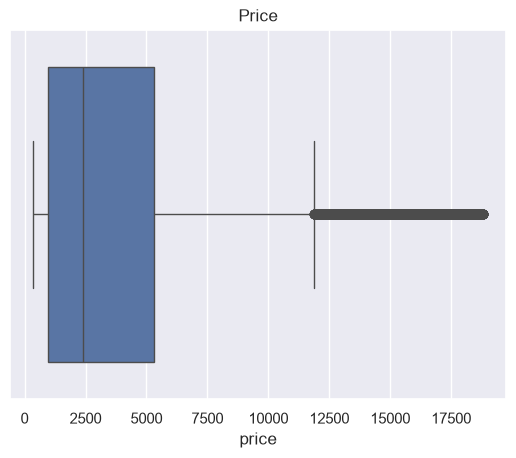

In [21]:
sns.boxplot(data= df, x="price")
plt.title("Price")
plt.show()

In [23]:
df.shape

(53920, 11)

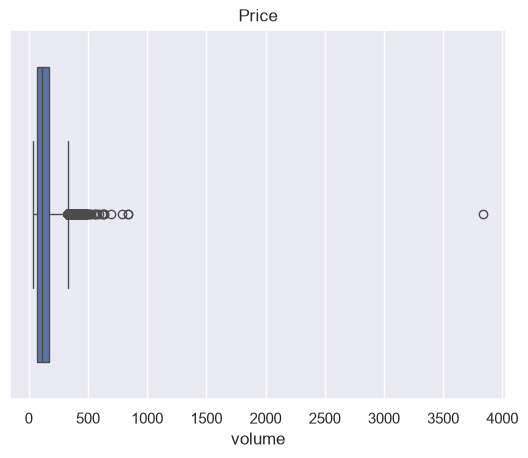

In [ ]:
sns.boxplot(data= df, x="volume")
plt.title("Price")
plt.show()


In [27]:
q1 = df["volume"].quantile(0.25)
q3 = df["volume"].quantile(0.75)

iqr = q3 -q1
high = q3 + 1.5 * iqr

outliers = df[df["volume"] > high]
print(f"Number of Outliers : {len(outliers)}")
outliers.sort_values("volume", ascending=False).head()

Number of Outliers : 1323


,carat,cut,color,clarity,depth,table,price,x,y,z,volume
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06,3840.598060
48410,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80,838.502400
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12,838.502400
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98,790.133208
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72,698.455296


In [35]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)

iqr = q3 - q1
high = q3 + 1.5 * iqr
print("Q1:", q1, " Q3:", q3, " IQR:", round(iqr, 1))
print("Above", round(high, 1), "is an outlier")
outliers = df[df["price"]>high]
print(f"Number of outliers: {len(outliers)}")
outliers.sort_values("price", ascending= False).head()

Q1: 951.0  Q3: 5324.0  IQR: 4373.0
Above 11883.5 is an outlier
Number of outliers: 3520


,carat,cut,color,clarity,depth,table,price,x,y,z,volume
27749,2.29,Premium,I,VS2,60.8,60.0,18823,8.50,8.47,5.16,371.494200
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04,317.333520
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56,249.029352
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11,340.663260
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01,318.636000


0.9040973038107564


<Axes: xlabel='price', ylabel='volume'>

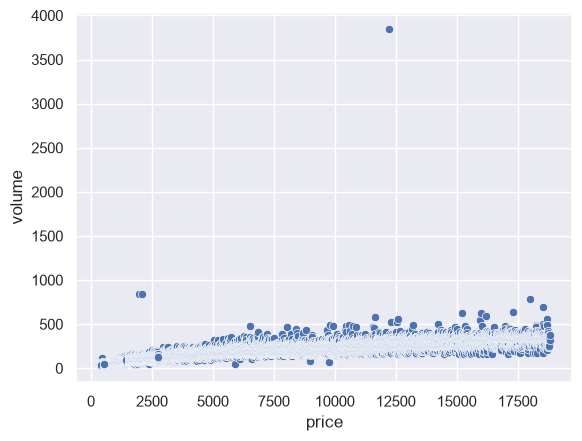

In [36]:
# find relation between prices and volume
print(df["volume"].corr(df["price"]))

sns.scatterplot(data=df, x="price", y="volume" )
